**Encoding methods**


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df_train = pd.read_csv("train.csv")
df_train.head(5)
#df_train.info()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
X = df_train.drop(["SalePrice"], axis = 1)
Y = df_train["SalePrice"]
X

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal


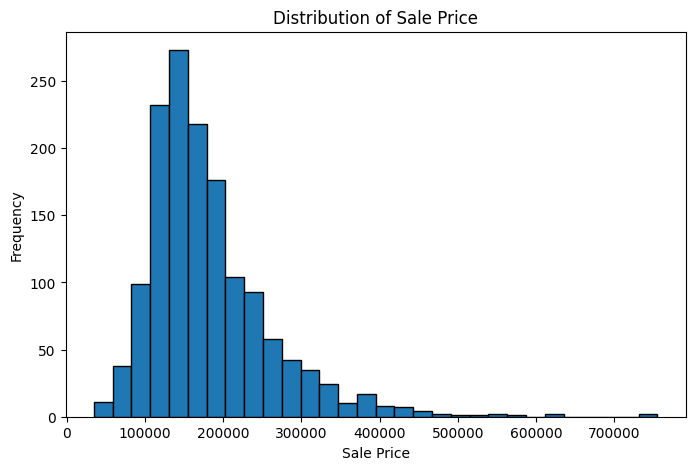

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(Y, bins=30, edgecolor='black')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

## Label Encoding with Linear Regression

The data preparation step separates the dataset into predictive features (X) by dropping the target column and isolates the target variable (Y) which represents the SalePrice of the houses. To handle the categorical text data in the columns, the code uses **pd.get_dummies(X, drop_first=True)**. This is the built-in pandas function that performs One-Hot Encoding. It automatically detects all your categorical columns and converts them into numeric columns filled with 1s and 0s.This process creates a brand-new binary column  for every unique category found across the categorical columns, dropping the first category to prevent redundant variables. Any remaining missing values are then replaced with zeros using .fillna(0)

The train_model function splits the newly expanded dataset into training and testing sets, 80% of the data to train and the remaining 20% for testing its accuracy. A **LinearRegression model** is initialized and fitted onto the training data to calculate the linear relationship between the encoded house characteristics and their respective prices. Once trained, the model generates price predictions for the unseen test houses.

The code evaluates how well the model performed by calculating two standard metrics. It prints a Mean Absolute Error of $20,315.17, which means the model's predictions are off by roughly $20,300 on average. It also prints an r2 Score of 0.8617, indicating that the one-hot encoded features successfully explain 86.17% of the variance in house prices. 

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

X = df_train.drop(columns=['SalePrice'])
Y = df_train['SalePrice']

X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.fillna(0)


def train_model(X_data, Y_data):
    X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, Y_train)

    predictions = model.predict(X_test)
    mae = mean_absolute_error(Y_test, predictions)
    r2 = r2_score(Y_test, predictions)

    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}")
    return model

trained_model = train_model(X_encoded, Y)



Mean Absolute Error: 20513.17
R2 Score: 0.6817


Mean Absolute Error: 20513.17
R2 Score: 0.6817


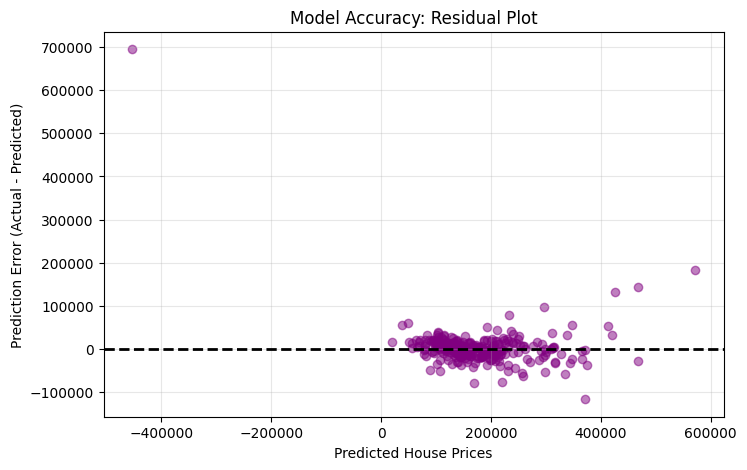

In [25]:
trained_model, Y_test, predictions = train_model(X_encoded, Y)


residuals = Y_test - predictions

plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, alpha=0.5, color="purple")
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.title("Model Accuracy: Residual Plot")
plt.xlabel("Predicted House Prices")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
from sklearn.feature_extraction import FeatureHasher
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

## Feature Hashing with Linear Regression
The code prepares the data by separating the target variable *(SalePrice)* from the predictive features. 
Because **feature hashing** requires text to compute hash values, all the input features in the dataframe are converted into strings using .astype(str).values. This prepares both the categorical and numerical columns to be processed uniformly by the hasher.

FeatureHasher is initialized with n_features=20. This step takes all 24 columns of data and uses a hashing function to map every single unique value into one of 20 fixed numerical columns. This turns the complex categorical information into a compact, fixed-size numerical matrix, which prevents the dataset from bloating in size the way traditional one-hot encoding would.

linear_model function splits this processed data into training and testing sets, 80% for training the model and 20% for testing its performance. A **LinearRegression** model is trained on the hashed features to find the relationship between the hashed columns and the  target price. Once trained, the model predicts house prices on the unseen test set, yielding a Mean Absolute Error of $38,518.78 (meaning its predictions are off by roughly $38,500 on average) and an r2 Score of 0.5344.

In [19]:
from sklearn.feature_extraction import FeatureHasher
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

X = df_train.drop(columns=["SalePrice"])
y = df_train["SalePrice"]

X_str = X.astype(str).values

hasher = FeatureHasher(n_features=20, input_type="string")
X_hashed = hasher.transform(X_str)


def linear_model(X_data, y_data):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, random_state=42, test_size=0.2
    )

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_test)

    print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")


linear_model(X_hashed, y)


Mean Absolute Error: 38518.70
R2 Score: 0.5344
